# Experiment Analysis

Compares models on both the `full` and `minimal` ablations.
Only features with data for **all** enabled models **and all ablations** are included.

**Terminology:**
- **feature** — one buggy Eiffel feature to fix; one record in the JSONL results.
- **attempt** — one fix iteration: AutoProof runs to get the error → LLM generates a fix → fix is applied → AutoProof verifies the result. Corresponds to `llm_interactions` in the data.
- **verification** — one AutoProof/Boogie/z3 execution (at least once per attempt).
- **ablation** — prompt configuration: `full` = all prompt parts enabled, `minimal` = all disabled.

In [1]:
# import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


In [2]:
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

_has_latex = shutil.which("latex") is not None

plt.rcParams.update({
    "text.usetex": _has_latex,
    "font.family": "serif",
    "font.size": 10,              # LLNCS base font size
    "figure.figsize": (4.80, 3.0),  # LLNCS text width = 12.2cm
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print(f"LaTeX rendering: {'enabled' if _has_latex else 'disabled (latex not found)'}")

LaTeX rendering: enabled


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
MODELS = [
    "anthropic/claude-sonnet-4.6",
    "openai/gpt-5-nano",
    "poolside/laguna-xs.2:free",
]
MODEL_LABELS = {
    "openai/gpt-5-nano":           "GPT-5 nano",
    "anthropic/claude-sonnet-4.6": "Sonnet 4.6",
    "poolside/laguna-xs.2:free":   "Laguna XS",
}
ABLATIONS       = ["full", "minimal"]
ABLATION_LABELS = {"full": "Full", "minimal": "Minimal"}
RESULTS_DIR     = Path("results")
MAX_ATTEMPTS    = 10
# Paul Tol colorblind-safe palette
COLORS = ["#4477AA", "#EE6677", "#228833"]
# Ablation distinction via hatch only (color encodes model)
ABLATION_HATCH = {"full": "", "minimal": "/"}

In [4]:
# ── Data loading ──────────────────────────────────────────────────────────────
def slug(m: str) -> str:
    return m.replace("/", "_").replace(":", "_")


def load_records_multi(results_dir, models, ablations):
    """Return {(model, ablation): [records]}."""
    out = {}
    for model in models:
        for ablation in ablations:
            records = []
            for ds_dir in sorted(results_dir.iterdir()):
                if not ds_dir.is_dir() or ds_dir.name == "html":
                    continue
                jf = ds_dir / slug(model) / f"{ablation}.jsonl"
                if not jf.exists():
                    continue
                for line in jf.read_text().splitlines():
                    line = line.strip()
                    if line and not line.startswith(">>"):
                        try:
                            rec = json.loads(line)
                            rec["dataset"] = ds_dir.name
                            records.append(rec)
                        except json.JSONDecodeError:
                            pass
            out[(model, ablation)] = records
    return out


def common_features(records_map):
    """Features present in ALL keys of records_map."""
    sets = [
        {(r["dataset"], r["class_name"], r["feature_name"]) for r in recs}
        for recs in records_map.values()
    ]
    return set.intersection(*sets) if sets else set()


def filter_by(records_map, key_set):
    return {k: [r for r in recs
                if (r["dataset"], r["class_name"], r["feature_name"]) in key_set]
            for k, recs in records_map.items()}


# ── Load everything ────────────────────────────────────────────────────────────
raw_ma = load_records_multi(RESULTS_DIR, MODELS, ABLATIONS)
common_ma = common_features(raw_ma)
data_ma = filter_by(raw_ma, common_ma)

# Drop 0-attempt features (dataset quality issue) and re-intersect across all combos
n_zero_ma = {k: sum(1 for r in recs if r["llm_interactions"] == 0)
             for k, recs in data_ma.items()}
data_ma = {k: [r for r in recs if r["llm_interactions"] > 0]
           for k, recs in data_ma.items()}
common_final = common_features(data_ma)
data_ma = filter_by(data_ma, common_final)

print(f"Common features across ALL (model × ablation) combos: {len(common_ma)}")
max_zero = max(n_zero_ma.values()) if n_zero_ma else 0
print(f"  dropped — 0-attempt: {max_zero}")
print(f"  remaining for analysis: {len(common_final)}\n")
print(f"{'(Model, Ablation)':<45} {'loaded':>6}  {'final':>6}")
for abl in ABLATIONS:
    for m in MODELS:
        k = (m, abl)
        print(f"  ({MODEL_LABELS[m]}, {ABLATION_LABELS[abl]})"
              f"{' ' * max(1, 40 - len(MODEL_LABELS[m]))}"
              f"{len(raw_ma[k]):>6}  {len(data_ma[k]):>6}")

Common features across ALL (model × ablation) combos: 546
  dropped — 0-attempt: 7
  remaining for analysis: 539

(Model, Ablation)                             loaded   final
  (Sonnet 4.6, Full)                                 546     539
  (GPT-5 nano, Full)                                 546     539
  (Laguna XS, Full)                                  546     539
  (Sonnet 4.6, Minimal)                                 546     539
  (GPT-5 nano, Minimal)                                 546     539
  (Laguna XS, Minimal)                                  546     539


In [5]:
# ── Dataset breakdown ─────────────────────────────────────────────────────────
from collections import Counter

# Count features per dataset in the raw loaded set (before 0-attempt filter)
raw_ds_counts = Counter(
    r["dataset"]
    for r in next(iter(raw_ma.values()))  # same across all combos before intersection
)
# Count features per dataset in the final common set
final_ds_counts = Counter(ds for ds, _, _ in common_final)

print(f"Features per dataset:")
print(f"\n  {'Dataset':<42}  {'loaded':>8}  {'final':>8}")
print(f"  {'─' * 42}  {'─' * 8}  {'─' * 8}")
for ds in sorted(raw_ds_counts):
    print(f"  {ds:<42}  {raw_ds_counts[ds]:>8}  {final_ds_counts.get(ds, 0):>8}")
print(f"  {'─' * 42}  {'─' * 8}  {'─' * 8}")
print(f"  {'Total':<42}  {sum(raw_ds_counts.values()):>8}  {len(common_final):>8}")

Features per dataset:

  Dataset                                       loaded     final
  ──────────────────────────────────────────  ────────  ────────
  buggy-java-jml-eiffel                            520       513
  maple-recursive                                   26        26
  ──────────────────────────────────────────  ────────  ────────
  Total                                            546       539


### OpenRouter Wait Times per Attempt

Sporadic queue delays only appear in the **tail** of the wait-time distribution.
The plots below combine data from both ablations (all records, not limited to common features) to maximise tail coverage.

Each data point is one attempt's OpenRouter round-trip time (`ai_request_time_seconds`).

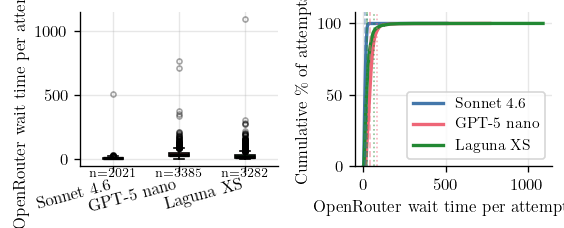

Model                          attempts      p50      p75      p95      max
  Sonnet 4.6                       2021      8.6     13.6     20.8    508.1
  GPT-5 nano                       3385     36.6     51.2     83.8    769.6
  Laguna XS                        3282     18.3     31.8     65.5   1094.1


In [6]:
# Collect per-attempt OpenRouter wait times from all ablations (better tail coverage)
ix_rows = []
for m in MODELS:
    for abl in ABLATIONS:
        for rec in raw_ma[(m, abl)]:
            for ix in (rec.get("interactions") or []):
                t = ix.get("ai_request_time_seconds")
                if t is not None:
                    ix_rows.append({"model": m, "label": MODEL_LABELS[m], "wait": t})
df_ix = pd.DataFrame(ix_rows)

fig, axes = plt.subplots(1, 2, figsize=(4.8, 2.0))

ax = axes[0]
box_data = [df_ix[df_ix["model"] == m]["wait"].values for m in MODELS]
bp = ax.boxplot(box_data, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                flierprops=dict(marker="o", markersize=3, alpha=0.35),
                showfliers=True)
for patch, c in zip(bp["boxes"], COLORS):
    patch.set_facecolor(c)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("OpenRouter wait time per attempt (s)")
for i, (m, d) in enumerate(zip(MODELS, box_data), 1):
    if len(d):
        ax.text(i, -ax.get_ylim()[1] * 0.06,
                f"n={len(d)}", ha="center", va="top", fontsize=7.5)

ax = axes[1]
for i, m in enumerate(MODELS):
    d = np.sort(df_ix[df_ix["model"] == m]["wait"].values)
    if len(d) == 0:
        continue
    cdf = np.arange(1, len(d) + 1) / len(d) * 100
    ax.plot(d, cdf, color=COLORS[i], linewidth=2, label=MODEL_LABELS[m])
ax.set_xlabel("OpenRouter wait time per attempt (s)")
ax.set_ylabel("Cumulative \\% of attempts")
ax.set_ylim(0, 108)
ax.legend(fontsize=9)
for i, m in enumerate(MODELS):
    d = df_ix[df_ix["model"] == m]["wait"].values
    if len(d) == 0:
        continue
    for pct, ls in [(50, "--"), (95, ":")]:
        v = np.percentile(d, pct)
        ax.axvline(v, color=COLORS[i], linestyle=ls, linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig("analysis_or_queue.pdf", bbox_inches="tight")
plt.show()

print(f"{'Model':<30} {'attempts':>8}  {'p50':>7}  {'p75':>7}  {'p95':>7}  {'max':>7}")
for m in MODELS:
    d = df_ix[df_ix["model"] == m]["wait"].values
    if len(d):
        print(f"  {MODEL_LABELS[m]:<28} {len(d):>8}  "
              f"{np.percentile(d,50):>7.1f}  {np.percentile(d,75):>7.1f}  "
              f"{np.percentile(d,95):>7.1f}  {np.max(d):>7.1f}")

**Figure 0.** OpenRouter wait time per attempt (left: box plot; right: CDF with p50/p95 markers). Combines both ablations for better tail coverage.

---

## Results: Full vs Minimal Prompt Ablation

Within each model group: left bar (solid) = `full` ablation, right bar (hatched `////`) = `minimal`.
All charts use the same common feature set.

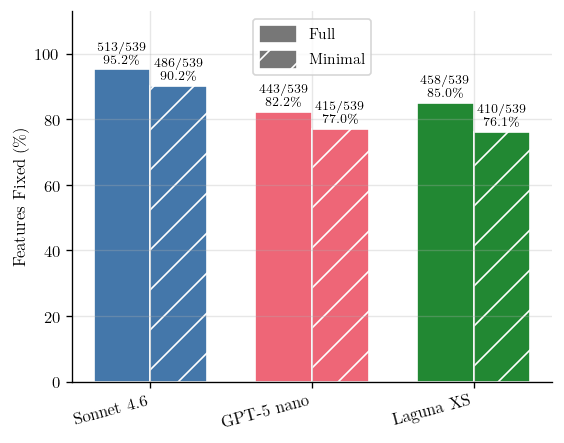


Model                         Ablation   fixed   total   rate %
  Sonnet 4.6                      Full     513     539     95.2
  GPT-5 nano                      Full     443     539     82.2
  Laguna XS                       Full     458     539     85.0
  Sonnet 4.6                   Minimal     486     539     90.2
  GPT-5 nano                   Minimal     415     539     77.0
  Laguna XS                    Minimal     410     539     76.1


In [7]:
### 1.  Success Rate
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(4.8, 3.8))

n_m = len(MODELS)
n_a = len(ABLATIONS)
group_w = 0.7
bar_w   = group_w / n_a
x = np.arange(n_m)

for ai, abl in enumerate(ABLATIONS):
    offset  = (ai - n_a / 2 + 0.5) * bar_w
    n_succ  = [sum(r["success"] for r in data_ma[(m, abl)]) for m in MODELS]
    n_total = [len(data_ma[(m, abl)]) for m in MODELS]
    rates   = [s / t * 100 if t else 0 for s, t in zip(n_succ, n_total)]
    bars = ax.bar(x + offset, rates, bar_w,
                  color=COLORS, hatch=ABLATION_HATCH[abl], edgecolor="white")
    for bar, s, t, r in zip(bars, n_succ, n_total, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
                f"{s}/{t}\n{r:.1f}\\%", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("Features Fixed (\\%)")
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_ylim(0, 113)

ablation_handles = [Patch(facecolor="#777777", hatch=ABLATION_HATCH[abl],
                          edgecolor="white", label=ABLATION_LABELS[abl])
                    for abl in ABLATIONS]
ax.legend(handles=ablation_handles, fontsize=9, handlelength=2.5, handleheight=1.5)

plt.tight_layout()
plt.savefig("analysis_1_success.pdf", bbox_inches="tight")
plt.show()

print(f"\n{'Model':<28}  {'Ablation':>8}  {'fixed':>6}  {'total':>6}  {'rate %':>7}")
for abl in ABLATIONS:
    for m in MODELS:
        recs = data_ma[(m, abl)]
        s = sum(r["success"] for r in recs)
        t = len(recs)
        print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  {s:>6}  {t:>6}  {s/t*100:>7.1f}")

**Figure 1.** Overall success rate (features fixed within 10 attempts) per model under full and minimal prompt ablation. Numbers above bars show fixed/total count and percentage.

In [8]:
# -- Ablation impact: minimal -> full success rate improvement
rates = {}
for abl in ABLATIONS:
    for m in MODELS:
        recs = data_ma[(m, abl)]
        rates[(m, abl)] = sum(r['success'] for r in recs) / len(recs) * 100

print(f"{'Model':<28}  {'Minimal':>8}  {'Full':>8}  {'delta (pp)':>10}")
print(f"  {'─'*26}  {'─'*8}  {'─'*8}  {'─'*10}")
deltas = []
for m in MODELS:
    full  = rates[(m, 'full')]
    mini  = rates[(m, 'minimal')]
    delta = full - mini
    deltas.append(delta)
    print(f"  {MODEL_LABELS[m]:<26}  {mini:>8.1f}  {full:>8.1f}  {delta:>+10.1f}")
print(f"  {'─'*26}  {'─'*8}  {'─'*8}  {'─'*10}")
avg_min   = sum(rates[(m, 'minimal')] for m in MODELS) / len(MODELS)
avg_full  = sum(rates[(m, 'full')]    for m in MODELS) / len(MODELS)
avg_delta = sum(deltas) / len(deltas)
print(f"  {'Average':<26}  {avg_min:>8.1f}  {avg_full:>8.1f}  {avg_delta:>+10.1f}")

Model                          Minimal      Full  delta (pp)
  ──────────────────────────  ────────  ────────  ──────────
  Sonnet 4.6                      90.2      95.2        +5.0
  GPT-5 nano                      77.0      82.2        +5.2
  Laguna XS                       76.1      85.0        +8.9
  ──────────────────────────  ────────  ────────  ──────────
  Average                         81.1      87.4        +6.4


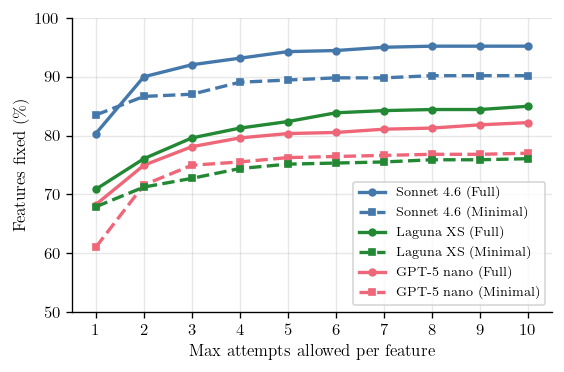

Model / Ablation                      1      2      3      4      5      6      7      8      9     10
──────────────────────────────────────────────────────────────────────────────────────────────────────
Sonnet 4.6 (Full)                  80.3   90.0   92.0   93.1   94.2   94.4   95.0   95.2   95.2   95.2
Sonnet 4.6 (Minimal)               83.5   86.6   87.0   89.1   89.4   89.8   89.8   90.2   90.2   90.2
GPT-5 nano (Full)                  68.3   75.0   78.1   79.6   80.3   80.5   81.1   81.3   81.8   82.2
GPT-5 nano (Minimal)               61.0   71.6   75.0   75.5   76.3   76.4   76.6   76.8   76.8   77.0
Laguna XS (Full)                   70.9   76.1   79.6   81.3   82.4   83.9   84.2   84.4   84.4   85.0
Laguna XS (Minimal)                67.9   71.2   72.7   74.4   75.1   75.3   75.5   75.9   75.9   76.1


In [9]:
### 2.  Cumulative Success Rate vs Attempt Budget
fig, ax = plt.subplots(figsize=(4.8, 3.2))
xs = list(range(1, MAX_ATTEMPTS + 1))

linestyles = {"full": "-", "minimal": "--"}
markers    = {"full": "o", "minimal": "s"}
cum_data = {}
for ci, m in enumerate(MODELS):
    for abl in ABLATIONS:
        recs = data_ma[(m, abl)]
        n = len(recs)
        if n == 0:
            continue
        ys = [sum(1 for r in recs if r["success"] and r["llm_interactions"] <= k) / n * 100
              for k in xs]
        cum_data[(m, abl)] = ys
        ax.plot(xs, ys,
                color=COLORS[ci], linewidth=2,
                linestyle=linestyles[abl], marker=markers[abl], markersize=4,
                label=f"{MODEL_LABELS[m]} ({ABLATION_LABELS[abl]})")

ax.set_xlabel("Max attempts allowed per feature")
ax.set_ylabel("Features fixed (\\%)")
ax.set_xticks(xs)
ax.set_xlim(0.5, MAX_ATTEMPTS + 0.5)
ax.set_ylim(50, 100)

# Legend order: Sonnet, Laguna, GPT-5 nano
handles, labels = ax.get_legend_handles_labels()
legend_model_order = [
    "anthropic/claude-sonnet-4.6",
    "poolside/laguna-xs.2:free",
] + [m for m in MODELS if m not in ("anthropic/claude-sonnet-4.6", "poolside/laguna-xs.2:free")]
order = [MODELS.index(m) * n_a + ai for m in legend_model_order for ai in range(n_a)]
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("analysis_2_cumulative.pdf", bbox_inches="tight")
plt.show()

# Textual table: rows = model x ablation, columns = attempt budget 1..MAX_ATTEMPTS
attempts = list(range(1, MAX_ATTEMPTS + 1))
col_w = 7
header = f"{'Model / Ablation':<32}" + "".join(f"{k:>{col_w}}" for k in attempts)
sep    = "─" * 32 + ("─" * col_w) * len(attempts)
print(header)
print(sep)
for m in MODELS:
    for abl in ABLATIONS:
        ys = cum_data.get((m, abl), [])
        label = f"{MODEL_LABELS[m]} ({ABLATION_LABELS[abl]})"
        row = f"{label:<32}" + "".join(f"{ys[k-1]:>{col_w}.1f}" for k in attempts)
        print(row)

**Figure 2.** Cumulative success rate as a function of the maximum attempt budget per feature. Solid lines = full ablation; dashed = minimal. Y-axis starts at 50% to highlight differences.

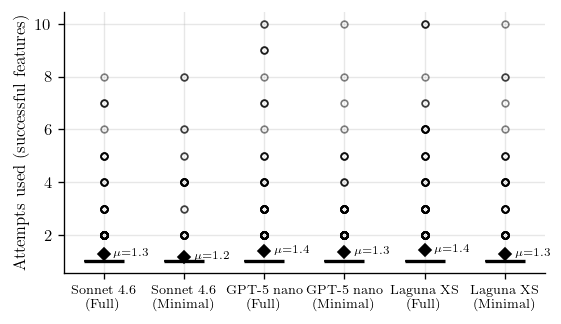

In [10]:
### 3a.  Attempt Count Distribution — Boxplots
from matplotlib.patches import Patch

box_vals, box_labels, box_colors, box_hatches = [], [], [], []
for ci, m in enumerate(MODELS):
    for abl in ABLATIONS:
        vals = [r["llm_interactions"] for r in data_ma[(m, abl)]
                if r["success"] and r["llm_interactions"] > 0]
        box_vals.append(vals)
        box_labels.append(f"{MODEL_LABELS[m]}\n({ABLATION_LABELS[abl]})")
        box_colors.append(COLORS[ci])
        box_hatches.append(ABLATION_HATCH[abl])

fig, ax = plt.subplots(figsize=(4.8, 2.8))
bp = ax.boxplot(box_vals, patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                flierprops=dict(marker="o", markersize=4, alpha=0.5))
for patch, color, hatch in zip(bp["boxes"], box_colors, box_hatches):
    patch.set_facecolor(color)
    patch.set_hatch(hatch)
ax.set_xticklabels(box_labels, fontsize=8)
ax.set_ylabel("Attempts used (successful features)")
for i, vals in enumerate(box_vals, 1):
    if vals:
        mn = np.mean(vals)
        ax.plot(i, mn, "D", color="black", zorder=5, ms=5)
        ax.text(i + 0.12, mn, f"$\\mu$={mn:.1f}", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("analysis_3a_attempts_box.pdf", bbox_inches="tight")
plt.show()

**Figure 3a.** Distribution of attempts used by successfully fixed features. Diamond markers show the mean.

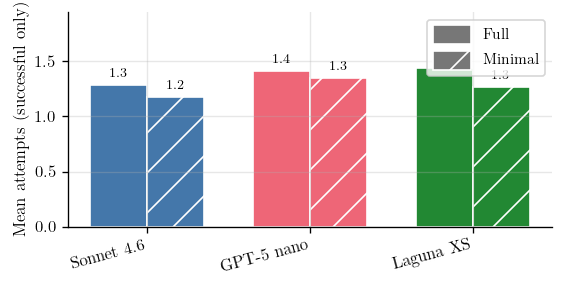


Model                         Ablation   fixed    mean   median   max
  Sonnet 4.6                      Full     513     1.3      1.0     8
  GPT-5 nano                      Full     443     1.4      1.0    10
  Laguna XS                       Full     458     1.4      1.0    10
  Sonnet 4.6                   Minimal     486     1.2      1.0     8
  GPT-5 nano                   Minimal     415     1.3      1.0    10
  Laguna XS                    Minimal     410     1.3      1.0    10


In [11]:
### 3b.  Mean Attempts per Model — Full vs Minimal
from matplotlib.patches import Patch

bar_w = 0.35
xpos  = np.arange(n_m)
all_means = []

fig, ax = plt.subplots(figsize=(4.8, 2.5))
for ai, abl in enumerate(ABLATIONS):
    means = []
    for m in MODELS:
        vals = [r["llm_interactions"] for r in data_ma[(m, abl)]
                if r["success"] and r["llm_interactions"] > 0]
        means.append(np.mean(vals) if vals else 0)
    all_means.extend(means)
    offset = (ai - len(ABLATIONS) / 2 + 0.5) * bar_w
    bars = ax.bar(xpos + offset, means, bar_w,
                  color=COLORS, hatch=ABLATION_HATCH[abl], edgecolor="white")
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{v:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(xpos)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("Mean attempts (successful only)")
ax.set_ylim(0, max(all_means) * 1.35)

ablation_handles = [Patch(facecolor="#777777", hatch=ABLATION_HATCH[abl],
                          edgecolor="white", label=ABLATION_LABELS[abl])
                    for abl in ABLATIONS]
ax.legend(handles=ablation_handles, fontsize=9, handlelength=2.5, handleheight=1.5,
          loc="upper right")

plt.tight_layout()
plt.savefig("analysis_3b_attempts_mean.pdf", bbox_inches="tight")
plt.show()

print(f"\n{'Model':<28}  {'Ablation':>8}  {'fixed':>6}  {'mean':>6}  {'median':>7}  {'max':>4}")
for abl in ABLATIONS:
    for m in MODELS:
        a = [r["llm_interactions"] for r in data_ma[(m, abl)]
             if r["success"] and r["llm_interactions"] > 0]
        if a:
            print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  {len(a):>6}  "
                  f"{np.mean(a):>6.1f}  {np.median(a):>7.1f}  {max(a):>4}")

**Figure 3b.** Mean number of attempts used by successfully fixed features, per model and ablation.

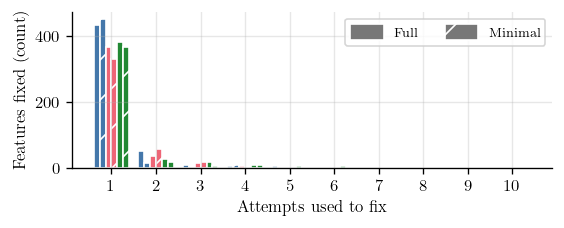

In [12]:
### 3b.  Features Fixed at Each Attempt Number — Full vs Minimal
from matplotlib.patches import Patch

xs    = np.arange(1, MAX_ATTEMPTS + 1)
combos = [(m, abl) for m in MODELS for abl in ABLATIONS]   # 6 bars per x
n_c    = len(combos)
bar_w  = 0.8 / n_c

fig, ax = plt.subplots(figsize=(4.8, 2.0))
for i, (m, abl) in enumerate(combos):
    counts = [
        sum(1 for r in data_ma[(m, abl)]
            if r["success"] and r["llm_interactions"] == k)
        for k in xs
    ]
    offset = (i - n_c / 2 + 0.5) * bar_w
    ci = MODELS.index(m)
    ax.bar(xs + offset, counts, bar_w,
           color=COLORS[ci], hatch=ABLATION_HATCH[abl], edgecolor="white")

ax.set_xlabel("Attempts used to fix")
ax.set_ylabel("Features fixed (count)")
ax.set_xticks(xs)

ablation_handles = [Patch(facecolor="#777777", hatch=ABLATION_HATCH[abl],
                          edgecolor="white", label=ABLATION_LABELS[abl])
                    for abl in ABLATIONS]
ax.legend(handles=ablation_handles, fontsize=8, ncol=2, handlelength=2.5, handleheight=1.5)
plt.tight_layout()
plt.savefig("analysis_3b_fixed_per_attempt.pdf", bbox_inches="tight")
plt.show()

**Figure 3c.** Number of features fixed at each specific attempt number (not cumulative).

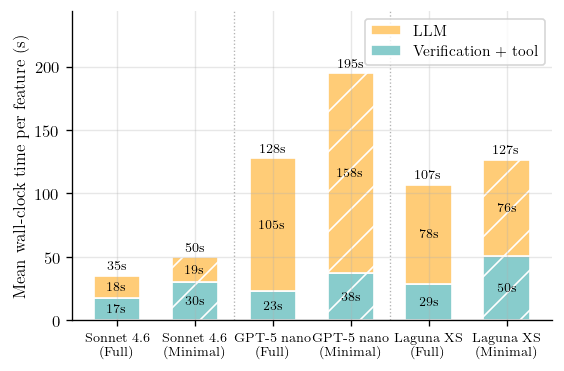


Model                         Ablation     total     verif      OR    other
  Sonnet 4.6                      Full      35.2       8.6    17.9      8.6
  GPT-5 nano                      Full     127.8      11.6   104.6     11.6
  Laguna XS                       Full     107.0      14.7    78.3     14.0
  Sonnet 4.6                   Minimal      49.6      15.3    19.1     15.2
  GPT-5 nano                   Minimal     195.2      20.1   157.5     17.5
  Laguna XS                    Minimal     126.7      25.4    76.2     25.0


In [13]:
### 4.  Time Breakdown per Feature — Full vs Minimal
time_rows_abl = []
for abl in ABLATIONS:
    for m in MODELS:
        for rec in data_ma[(m, abl)]:
            ixs   = rec.get("interactions") or []
            total = rec.get("total_elapsed_time_seconds") or 0.0
            verif = sum((ix.get("verification_time_seconds") or 0.0) for ix in ixs)
            llm   = sum((ix.get("ai_request_time_seconds")  or 0.0) for ix in ixs)
            other = max(0.0, total - verif - llm)
            time_rows_abl.append({
                "model": m, "ablation": abl,
                "combo": f"{m}|{abl}",
                "total": total, "verification": verif, "openrouter": llm, "other": other,
            })
df_ta = pd.DataFrame(time_rows_abl)

combo_keys    = [f"{m}|{abl}" for m in MODELS for abl in ABLATIONS]
combo_labels  = [f"{MODEL_LABELS[m]}\n({ABLATION_LABELS[abl]})" for m in MODELS for abl in ABLATIONS]
combo_colors  = [COLORS[ci] for ci, m in enumerate(MODELS) for abl in ABLATIONS]
combo_hatches = [ABLATION_HATCH[abl] for m in MODELS for abl in ABLATIONS]
x = np.arange(len(combo_labels))

fig, ax = plt.subplots(figsize=(4.8, 3.2))
means_ta = df_ta.groupby("combo")[["verification", "openrouter", "other"]].mean().reindex(combo_keys)
means_ta["autoproof"] = means_ta["verification"] + means_ta["other"]

tc = [("autoproof",  "#88CCCC", "Verification + tool"),
      ("openrouter", "#FFCC77", "LLM")]
bottom = np.zeros(len(combo_labels))

for col, tc_col, lbl in tc:
    vals = means_ta[col].values
    for xi, (v, b, hatch) in enumerate(zip(vals, bottom, combo_hatches)):
        ax.bar(xi, v, 0.6, bottom=b, color=tc_col, hatch=hatch, edgecolor="white",
               label=lbl if xi == 0 else None)
        if v > 4:
            ax.text(xi, b + v / 2, f"{v:.0f}s", ha="center", va="center", fontsize=7.5,
                    color="black")
    bottom += vals

for xi, total in enumerate(bottom):
    ax.text(xi, total + max(bottom) * 0.015, f"{total:.0f}s",
            ha="center", va="bottom", fontsize=8, fontweight="bold")
for sep in [1.5, 3.5]:
    ax.axvline(sep, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(combo_labels, fontsize=8)
ax.set_ylabel("Mean wall-clock time per feature (s)")
ax.set_ylim(0, max(bottom) * 1.25)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("analysis_4_time.pdf", bbox_inches="tight")
plt.show()

print(f"\n{'Model':<28}  {'Ablation':>8}  {'total':>8}  {'verif':>8}  {'OR':>6}  {'other':>7}")
for abl in ABLATIONS:
    for m in MODELS:
        sub = df_ta[(df_ta["model"] == m) & (df_ta["ablation"] == abl)]
        if sub.empty: continue
        print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  "
              f"{sub.total.mean():>8.1f}  {sub.verification.mean():>8.1f}  "
              f"{sub.openrouter.mean():>6.1f}  {sub.other.mean():>7.1f}")

**Figure 4.** Mean wall-clock time per feature broken down by component: verification (AutoProof/Boogie/z3), OpenRouter wait, and other overhead. Hatch encodes ablation.

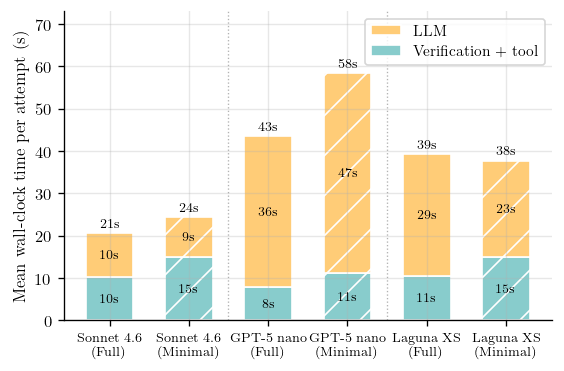


Model                         Ablation     total     verif     LLM    other
  Sonnet 4.6                      Full      20.6       5.1    10.5      5.1
  GPT-5 nano                      Full      43.5       4.0    35.6      3.9
  Laguna XS                       Full      39.2       5.4    28.7      5.1
  Sonnet 4.6                   Minimal      24.3       7.5     9.4      7.4
  GPT-5 nano                   Minimal      58.4       6.0    47.2      5.2
  Laguna XS                    Minimal      37.7       7.6    22.7      7.4


In [14]:
### 4b.  Time Breakdown per Attempt — Full vs Minimal
att_time_rows = []
for abl in ABLATIONS:
    for m in MODELS:
        for rec in data_ma[(m, abl)]:
            ixs = rec.get("interactions") or []
            n   = len(ixs)
            if n == 0:
                continue
            total     = rec.get("total_elapsed_time_seconds") or 0.0
            verif_tot = sum((ix.get("verification_time_seconds") or 0.0) for ix in ixs)
            llm_tot   = sum((ix.get("ai_request_time_seconds")  or 0.0) for ix in ixs)
            other_tot = max(0.0, total - verif_tot - llm_tot)
            for ix in ixs:
                att_time_rows.append({
                    "model": m, "ablation": abl, "combo": f"{m}|{abl}",
                    "verification": ix.get("verification_time_seconds") or 0.0,
                    "openrouter":   ix.get("ai_request_time_seconds")  or 0.0,
                    "other":        other_tot / n,  # overhead distributed evenly across attempts
                })
df_ta_att = pd.DataFrame(att_time_rows)

fig, ax = plt.subplots(figsize=(4.8, 3.2))
means_att = df_ta_att.groupby("combo")[["verification", "openrouter", "other"]].mean().reindex(combo_keys)
means_att["autoproof"] = means_att["verification"] + means_att["other"]

tc = [("autoproof",  "#88CCCC", "Verification + tool"),
      ("openrouter", "#FFCC77", "LLM")]
bottom = np.zeros(len(combo_labels))

for col, tc_col, lbl in tc:
    vals = means_att[col].values
    for xi, (v, b, hatch) in enumerate(zip(vals, bottom, combo_hatches)):
        ax.bar(xi, v, 0.6, bottom=b, color=tc_col, hatch=hatch, edgecolor="white",
               label=lbl if xi == 0 else None)
        if v > 1:
            ax.text(xi, b + v / 2, f"{v:.0f}s", ha="center", va="center", fontsize=7.5,
                    color="black")
    bottom += vals

for xi, total in enumerate(bottom):
    ax.text(xi, total + max(bottom) * 0.015, f"{total:.0f}s",
            ha="center", va="bottom", fontsize=8, fontweight="bold")
for sep in [1.5, 3.5]:
    ax.axvline(sep, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(combo_labels, fontsize=8)
ax.set_ylabel("Mean wall-clock time per attempt (s)")
ax.set_ylim(0, max(bottom) * 1.25)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("analysis_4b_time_attempt.pdf", bbox_inches="tight")
plt.show()

print(f"\n{'Model':<28}  {'Ablation':>8}  {'total':>8}  {'verif':>8}  {'LLM':>6}  {'other':>7}")
for abl in ABLATIONS:
    for m in MODELS:
        sub = df_ta_att[(df_ta_att["model"] == m) & (df_ta_att["ablation"] == abl)]
        if sub.empty: continue
        t = sub.verification.mean() + sub.openrouter.mean() + sub.other.mean()
        print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  "
              f"{t:>8.1f}  {sub.verification.mean():>8.1f}  "
              f"{sub.openrouter.mean():>6.1f}  {sub.other.mean():>7.1f}")

**Figure 4b.** Mean wall-clock time per attempt (one LLM call + verification round). "Other" overhead is distributed evenly across the attempts of each feature.

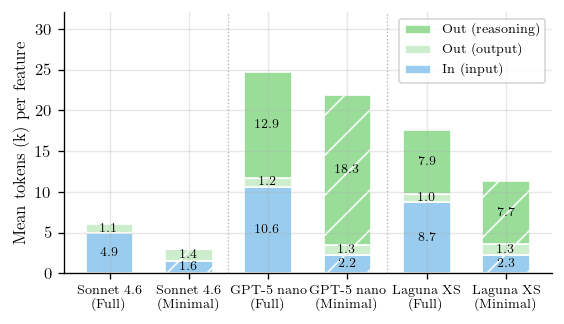

In [15]:
### 5a.  Token Usage per Feature — Full vs Minimal
feat_rows_abl, att_rows_abl = [], []
for abl in ABLATIONS:
    for m in MODELS:
        for rec in data_ma[(m, abl)]:
            f_pt = f_out = f_rt = f_cost = 0
            for ix in rec.get("interactions") or []:
                a_pt = a_out = a_rt = a_cost = 0
                for s in ix.get("suggestions") or []:
                    pt   = s.get("prompt_tokens", 0) or 0
                    ct   = s.get("completion_tokens", 0) or 0
                    rt   = (s.get("completion_tokens_details") or {}).get("reasoning_tokens", 0) or 0
                    cost = s.get("cost", 0) or 0
                    a_pt += pt;  a_out += ct - rt;  a_rt += rt;  a_cost += cost
                    f_pt += pt;  f_out += ct - rt;  f_rt += rt;  f_cost += cost
                att_rows_abl.append({"model": m, "ablation": abl, "combo": f"{m}|{abl}",
                                     "prompt": a_pt, "output": a_out,
                                     "reasoning": a_rt, "cost": a_cost})
            feat_rows_abl.append({"model": m, "ablation": abl, "combo": f"{m}|{abl}",
                                   "prompt": f_pt, "output": f_out,
                                   "reasoning": f_rt, "cost": f_cost})

df_feat_abl = pd.DataFrame(feat_rows_abl)
df_att_abl  = pd.DataFrame(att_rows_abl)

# Shared layout variables reused in 5b–5d
_tok_keys    = combo_keys   # defined in cell 4
_tok_labels  = combo_labels
_tok_hatches = combo_hatches
_x_tok       = np.arange(len(_tok_labels))
_light_colors = ["#99CCEE", "#FFAAAA", "#99DD99"]  # lighter Paul Tol
_light_combo  = [_light_colors[ci] for ci, m in enumerate(MODELS) for _ in ABLATIONS]
# IN=blue; OUT split into output (medium green) + reasoning (dark green)
_tok_colors = {"prompt": "#99CCEE", "output": "#CCEECC", "reasoning": "#99DD99"}

def _draw_tok_bars(ax, df, title):
    g = df.groupby("combo")[["prompt", "output", "reasoning"]].mean().reindex(_tok_keys)
    bottom = np.zeros(len(_tok_keys))
    labels = {"prompt": "In (input)", "output": "Out (output)", "reasoning": "Out (reasoning)"}
    for col, color in _tok_colors.items():
        vals = g[col].values
        for xi, (v, b, hatch) in enumerate(zip(vals, bottom, _tok_hatches)):
            ax.bar(xi, v / 1000, 0.6, bottom=b / 1000, color=color, hatch=hatch, edgecolor="white",
                   label=labels[col] if xi == 0 else None)
            if v > 80:
                ax.text(xi, (b + v / 2) / 1000, f"{v / 1000:.1f}",
                        ha="center", va="center", fontsize=7.5, color="black")
        bottom += vals
    for sep in [1.5, 3.5]:
        ax.axvline(sep, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_xticks(_x_tok)
    ax.set_xticklabels(_tok_labels, fontsize=8)
    ax.set_ylabel(f"Mean tokens (k) {title}")
    ax.set_ylim(0, max(bottom) / 1000 * 1.3)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], fontsize=8, loc="upper right")

fig, ax = plt.subplots(figsize=(4.8, 2.8))
_draw_tok_bars(ax, df_feat_abl, "per feature")
plt.tight_layout()
plt.savefig("analysis_5a_tokens_feature.pdf", bbox_inches="tight")
plt.show()


**Figure 5a.** Mean token usage per feature (prompt + output + reasoning tokens). Hatch encodes ablation.

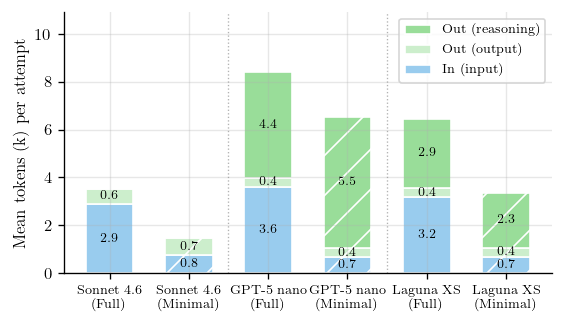

Token usage per feature (mean):
Model                         Ablation    prompt    output    reason
  Sonnet 4.6                      Full      4946      1057         0
  GPT-5 nano                      Full     10587      1160     12932
  Laguna XS                       Full      8701      1021      7884
  Sonnet 4.6                   Minimal      1557      1429         0
  GPT-5 nano                   Minimal      2213      1305     18319
  Laguna XS                    Minimal      2273      1313      7707


In [16]:
### 5b.  Token Usage per Attempt — Full vs Minimal
fig, ax = plt.subplots(figsize=(4.8, 2.8))
_draw_tok_bars(ax, df_att_abl, "per attempt")
plt.tight_layout()
plt.savefig("analysis_5b_tokens_attempt.pdf", bbox_inches="tight")
plt.show()

print("Token usage per feature (mean):")
print(f"{'Model':<28}  {'Ablation':>8}  {'prompt':>8}  {'output':>8}  {'reason':>8}")
for abl in ABLATIONS:
    for m in MODELS:
        sub = df_feat_abl[(df_feat_abl["model"] == m) & (df_feat_abl["ablation"] == abl)]
        if sub.empty: continue
        print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  "
              f"{sub.prompt.mean():>8.0f}  {sub.output.mean():>8.0f}  {sub.reasoning.mean():>8.0f}")

**Figure 5b.** Mean token usage per attempt (one LLM call).

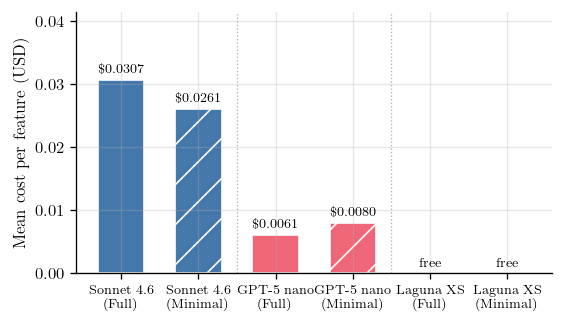

In [17]:
### 5c.  Cost per Feature — Full vs Minimal
def _draw_cost_bars(ax, df, ylabel):
    means = df.groupby("combo")["cost"].mean().reindex(_tok_keys)
    max_v = max(means.values) or 1
    for xi, (v, color, hatch) in enumerate(zip(means.values, combo_colors, _tok_hatches)):
        ax.bar(xi, v, 0.6, color=color, hatch=hatch, edgecolor="white")
        lbl = f"\\${v:.4f}" if v >= 0.0001 else "free"
        ax.text(xi, v + max_v * 0.02, lbl, ha="center", va="bottom", fontsize=8)
    for sep in [1.5, 3.5]:
        ax.axvline(sep, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_xticks(_x_tok)
    ax.set_xticklabels(_tok_labels, fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max_v * 1.35)

fig, ax = plt.subplots(figsize=(4.8, 2.8))
_draw_cost_bars(ax, df_feat_abl, "Mean cost per feature (USD)")
plt.tight_layout()
plt.savefig("analysis_5c_cost_feature.pdf", bbox_inches="tight")
plt.show()

**Figure 5c.** Mean cost per feature (USD). "free" = model reported zero cost.

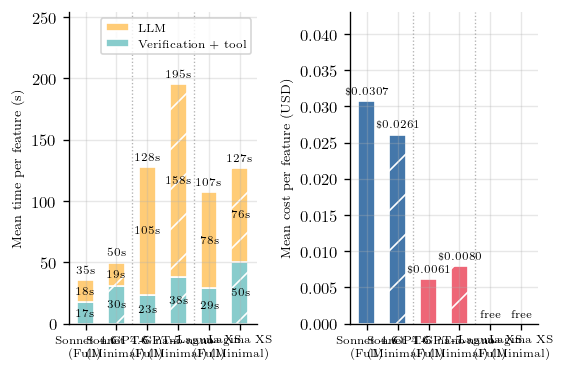

In [18]:
### Fig 4 + 5c  — Time and Cost side by side
fig, axes = plt.subplots(1, 2, figsize=(4.8, 3.2))

# ── Left: time breakdown (verification+tool | LLM) ────────────────────────
ax = axes[0]
mt = df_ta.groupby("combo")[["verification", "openrouter", "other"]].mean().reindex(combo_keys)
mt_ap = (mt["verification"] + mt["other"]).values
mt_or = mt["openrouter"].values
bottom = np.zeros(len(combo_keys))
for vals, color, lbl in [(mt_ap, "#88CCCC", "Verification + tool"),
                          (mt_or, "#FFCC77", "LLM")]:
    for xi, (v, b, hatch) in enumerate(zip(vals, bottom, combo_hatches)):
        ax.bar(xi, v, 0.55, bottom=b, color=color, hatch=hatch, edgecolor="white",
               label=lbl if xi == 0 else None)
        if v > 8:
            ax.text(xi, b + v / 2, f"{v:.0f}s", ha="center", va="center",
                    fontsize=6.5, color="black")
    bottom += vals
for xi, total in enumerate(bottom):
    ax.text(xi, total + max(bottom) * 0.02, f"{total:.0f}s",
            ha="center", va="bottom", fontsize=7, fontweight="bold")
for sep in [1.5, 3.5]:
    ax.axvline(sep, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.set_xticks(range(len(combo_labels)))
ax.set_xticklabels(combo_labels, fontsize=7)
ax.set_ylabel("Mean time per feature (s)", fontsize=8)
ax.set_ylim(0, max(bottom) * 1.3)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], fontsize=7, loc="upper right")

# ── Right: cost per feature ────────────────────────────────────────────────
ax = axes[1]
means_cost = df_feat_abl.groupby("combo")["cost"].mean().reindex(_tok_keys)
max_v = max(means_cost.values) or 1
for xi, (v, color, hatch) in enumerate(zip(means_cost.values, combo_colors, _tok_hatches)):
    ax.bar(xi, v, 0.55, color=color, hatch=hatch, edgecolor="white")
    lbl = f"\\${v:.4f}" if v >= 0.0001 else "free"
    ax.text(xi, v + max_v * 0.02, lbl, ha="center", va="bottom", fontsize=6.5)
for sep in [1.5, 3.5]:
    ax.axvline(sep, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.set_xticks(_x_tok)
ax.set_xticklabels(_tok_labels, fontsize=7)
ax.set_ylabel("Mean cost per feature (USD)", fontsize=8)
ax.set_ylim(0, max_v * 1.4)

plt.tight_layout()
plt.savefig("analysis_4_5c.pdf", bbox_inches="tight")
plt.show()

**Figure 4+5c (combined).** Left: mean wall-clock time per feature (verification + framework overhead vs OpenRouter wait). Right: mean cost per feature (USD). Both share the same x-axis grouping (model × ablation). Saved as `analysis_4_5c.pdf`.

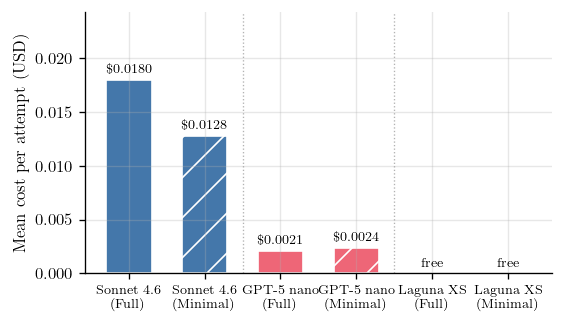


Cost per feature / per attempt (mean):
Model                         Ablation   per feat    per att
  Sonnet 4.6                      Full   \$0.0307   \$0.0180
  GPT-5 nano                      Full   \$0.0061   \$0.0021
  Laguna XS                       Full       free       free
  Sonnet 4.6                   Minimal   \$0.0261   \$0.0128
  GPT-5 nano                   Minimal   \$0.0080   \$0.0024
  Laguna XS                    Minimal       free       free


In [19]:
### 5d.  Cost per Attempt — Full vs Minimal
fig, ax = plt.subplots(figsize=(4.8, 2.8))
_draw_cost_bars(ax, df_att_abl, "Mean cost per attempt (USD)")
plt.tight_layout()
plt.savefig("analysis_5d_cost_attempt.pdf", bbox_inches="tight")
plt.show()

print("\nCost per feature / per attempt (mean):")
print(f"{'Model':<28}  {'Ablation':>8}  {'per feat':>9}  {'per att':>9}")
for abl in ABLATIONS:
    for m in MODELS:
        sf = df_feat_abl[(df_feat_abl["model"] == m) & (df_feat_abl["ablation"] == abl)]
        sa = df_att_abl[ (df_att_abl["model"]  == m) & (df_att_abl["ablation"]  == abl)]
        if sf.empty: continue
        cf = sf.cost.mean(); ca = sa.cost.mean()
        print(f"  {MODEL_LABELS[m]:<26}  {ABLATION_LABELS[abl]:>8}  "
              f"{'free' if cf == 0 else f'\\${cf:.4f}':>9}  "
              f"{'free' if ca == 0 else f'\\${ca:.4f}':>9}")

**Figure 5d.** Mean cost per attempt (USD).

In [20]:
### Cost comparison: how many times more expensive is Sonnet?
sonnet_id = "anthropic/claude-sonnet-4.6"

def _mean_cost(df, m, abl):
    sub = df[(df["model"] == m) & (df["ablation"] == abl)]
    return sub["cost"].mean() if not sub.empty else 0.0

def _fmt(v):
    return f"${v:.5f}" if v >= 0.0001 else "free"

def _ratio(sonnet_v, other_v, invert=False):
    if other_v == 0 and sonnet_v == 0:
        return "equal"
    if other_v == 0:
        return "∞" if not invert else "0.0x"
    r = sonnet_v / other_v if not invert else other_v / sonnet_v
    return f"{r:.1f}x"

for scope, df in [("per feature", df_feat_abl), ("per attempt", df_att_abl)]:
    print(f"Cost {scope}  —  ratio = Sonnet / model  (>1 means Sonnet is more expensive)\n")
    col_w = 11
    hdr = (f"  {'Model':<26}"
           + "".join(f"  {ABLATION_LABELS[a]+' cost':>{col_w}}" for a in ABLATIONS)
           + "".join(f"  {ABLATION_LABELS[a]+' ratio':>{col_w}}" for a in ABLATIONS))
    print(hdr)
    print("  " + "─" * (len(hdr) - 2))
    for m in MODELS:
        costs = [_mean_cost(df, m, a) for a in ABLATIONS]
        s_costs = [_mean_cost(df, sonnet_id, a) for a in ABLATIONS]
        cost_cols  = "".join(f"  {_fmt(c):>{col_w}}" for c in costs)
        ratio_cols = "".join(f"  {_ratio(s_costs[i], costs[i]):>{col_w}}" for i in range(len(ABLATIONS)))
        print(f"  {MODEL_LABELS[m]:<26}" + cost_cols + ratio_cols)
    print()

Cost per feature  —  ratio = Sonnet / model  (>1 means Sonnet is more expensive)

  Model                         Full cost  Minimal cost   Full ratio  Minimal ratio
  ─────────────────────────────────────────────────────────────────────────────────
  Sonnet 4.6                     $0.03070     $0.02611         1.0x         1.0x
  GPT-5 nano                     $0.00611     $0.00796         5.0x         3.3x
  Laguna XS                          free         free            ∞            ∞

Cost per attempt  —  ratio = Sonnet / model  (>1 means Sonnet is more expensive)

  Model                         Full cost  Minimal cost   Full ratio  Minimal ratio
  ─────────────────────────────────────────────────────────────────────────────────
  Sonnet 4.6                     $0.01800     $0.01277         1.0x         1.0x
  GPT-5 nano                     $0.00208     $0.00238         8.7x         5.4x
  Laguna XS                          free         free            ∞            ∞



In [21]:
### Time comparison: how many times more/less time does Sonnet take per feature?
def _mean_time(df, m, abl, col="total"):
    sub = df[(df["model"] == m) & (df["ablation"] == abl)]
    return sub[col].mean() if not sub.empty else 0.0

for scope, df in [("per feature", df_ta), ("per attempt", df_ta_att)]:
    total_col = "total" if scope == "per feature" else None
    if scope == "per attempt":
        # df_ta_att has verification + openrouter + other; sum them for total
        df = df_ta_att.copy()
        df["total"] = df["verification"] + df["openrouter"] + df["other"]

    print(f"Wall-clock time {scope}  —  ratio = Sonnet / model  (>1 means Sonnet takes longer)\n")
    col_w = 12
    hdr = (f"  {'Model':<26}"
           + "".join(f"  {ABLATION_LABELS[a]+' time (s)':>{col_w}}" for a in ABLATIONS)
           + "".join(f"  {ABLATION_LABELS[a]+' ratio':>{col_w}}" for a in ABLATIONS))
    print(hdr)
    print("  " + "─" * (len(hdr) - 2))
    for m in MODELS:
        times   = [_mean_time(df, m, a) for a in ABLATIONS]
        s_times = [_mean_time(df, sonnet_id, a) for a in ABLATIONS]
        time_cols  = "".join(f"  {t:>{col_w}.1f}" for t in times)
        ratio_cols = "".join(f"  {_ratio(s_times[i], times[i]):>{col_w}}" for i in range(len(ABLATIONS)))
        print(f"  {MODEL_LABELS[m]:<26}" + time_cols + ratio_cols)
    print()

Wall-clock time per feature  —  ratio = Sonnet / model  (>1 means Sonnet takes longer)

  Model                       Full time (s)  Minimal time (s)    Full ratio  Minimal ratio
  ────────────────────────────────────────────────────────────────────────────────────────
  Sonnet 4.6                          35.2          49.6          1.0x          1.0x
  GPT-5 nano                         127.8         195.2          0.3x          0.3x
  Laguna XS                          107.0         126.7          0.3x          0.4x

Wall-clock time per attempt  —  ratio = Sonnet / model  (>1 means Sonnet takes longer)

  Model                       Full time (s)  Minimal time (s)    Full ratio  Minimal ratio
  ────────────────────────────────────────────────────────────────────────────────────────
  Sonnet 4.6                          20.6          24.3          1.0x          1.0x
  GPT-5 nano                          43.5          58.4          0.5x          0.4x
  Laguna XS                       

---

## 6. Prompt Example — Full vs Minimal

Shows the actual prompts sent to the LLM for one feature, both ablations.
System and user message boundaries are displayed explicitly.

In [22]:
import re as _re

def _split_prompt(prompt):
    """
    Split a prompt (str or list-of-messages) into [(role, content), ...].

    Handles two formats:
      • list of {"role": ..., "content": ...} dicts  (OpenAI messages API)
      • flat string with 'System:', 'User:', 'Assistant:' section headers
        at the start of a line (the format used in these experiments)
    """
    if isinstance(prompt, list):
        return [(msg.get("role", "unknown"),
                 msg.get("content", "") if isinstance(msg.get("content"), str)
                 else "\n".join((p.get("text","") if isinstance(p,dict) else str(p))
                                for p in msg.get("content",[])))
                for msg in prompt]

    if isinstance(prompt, str):
        pattern = _re.compile(r'^(System|User|Assistant):\s?', _re.MULTILINE)
        parts = pattern.split(prompt)
        # parts = ['', 'System', 'text...', 'User', 'text...', ...]
        # or ['preamble', 'System', 'text...', ...] if there's content before first header
        roles, texts = [], []
        i = 0
        if parts[0].strip():          # content before first header — treat as preamble
            roles.append("(preamble)")
            texts.append(parts[0].rstrip())
            i = 1
        else:
            i = 1                     # skip the empty leading string
        while i + 1 < len(parts):
            roles.append(parts[i].lower())
            texts.append(parts[i + 1].rstrip())
            i += 2
        return list(zip(roles, texts))

    return [("unknown", repr(prompt))]


def show_prompt_pair(m, feature_idx=0):
    """Print interaction-0 prompts for both ablations of a given model."""
    r_full = data_ma[(m, "full")][feature_idx]
    key = (r_full["dataset"], r_full["class_name"], r_full["feature_name"])
    r_min = next(
        (r for r in data_ma[(m, "minimal")]
         if (r["dataset"], r["class_name"], r["feature_name"]) == key),
        None,
    )
    if r_min is None:
        print("Feature not found in minimal ablation — try a different index.")
        return

    print(f"Model  : {MODEL_LABELS[m]}")
    print(f"Dataset: {key[0]}   Class: {key[1]}   Feature: {key[2]}")

    W = 90
    for abl, rec in [("full", r_full), ("minimal", r_min)]:
        ix = (rec.get("interactions") or [{}])[0]
        prompt = ix.get("prompt") or ix.get("messages") or []

        print(f"\n{'█' * W}")
        print(f"  ABLATION: {ABLATION_LABELS[abl].upper()}  ({abl})")
        print(f"{'█' * W}")

        if not prompt:
            print("  (no prompt recorded)")
            continue

        for role, content in _split_prompt(prompt):
            print(f"\n{'─' * W}")
            print(f"  ▶  {role.upper()}")
            print(f"{'─' * W}")
            print(content)

    print(f"\n{'═' * W}")


# Show the first common feature for the first model.
# Change feature_idx or m to browse other examples.
show_prompt_pair(MODELS[0], feature_idx=0)

Model  : Sonnet 4.6
Dataset: buggy-java-jml-eiffel   Class: LCM_1   Feature: div

██████████████████████████████████████████████████████████████████████████████████████████
  ABLATION: FULL  (full)
██████████████████████████████████████████████████████████████████████████████████████████

──────────────────────────────────────────────────────────────────────────────────────────
  ▶  SYSTEM
──────────────────────────────────────────────────────────────────────────────────────────
You are a coding assistant, expert in the Eiffel programming language and AutoProof static verifier.
You will receive context about a class followed by an Eiffel feature that does not verify, and the AutoProof error.
Respond with a corrected version of the feature.
IMPORTANT: You must ONLY modify the feature body (the code between 'do' and 'end') and/or the local variable declarations (the 'local' clause).
You must NOT modify:
- The feature signature (name, parameters, return type)
- Notes (the 'note' clause)
-